In [2]:
## Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [6]:
## Task 1
## Load Dataset
df = pd.read_csv("customer_churn_nn.csv")

df.head()


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [7]:
## Dataset shape
print("Rows and Columns:", df.shape)

Rows and Columns: (2000, 17)


In [8]:
## Data Types
print(df.dtypes)

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [9]:
## Missing Value
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [10]:
## Statistical summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


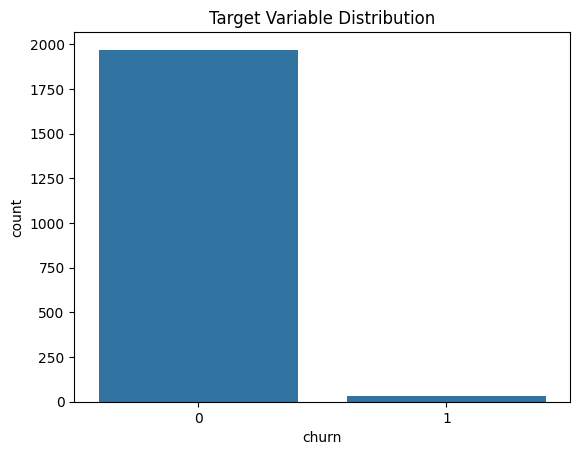

In [11]:
## Target Distribution
sns.countplot(x="churn", data=df)
plt.title("Target Variable Distribution")
plt.show()

Markdown Interpretation
churn is the target variable
1 = customer churned
0 = customer retained
Distribution helps detect class imbalance

In [12]:
## Task 2
## Drop identifier coloumn
df = df.drop(columns=["customer_id"])

In [13]:
## Separate features and target
X = df.drop("churn", axis=1)
y = df["churn"]

In [14]:
## Identify categorical and numerical problems
categorical_cols = ["region", "plan_type", "contract_type", "payment_method"]

numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [15]:
## Preprocessing Pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [16]:
## train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
## Applying Transformations
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
## Task 3
def create_model(hidden_neurons=32, learning_rate=0.001, activation="relu"):
    
    model = Sequential([
        Dense(hidden_neurons, activation=activation,
              input_shape=(X_train_processed.shape[1],)),
        
        Dense(16, activation=activation),
        
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

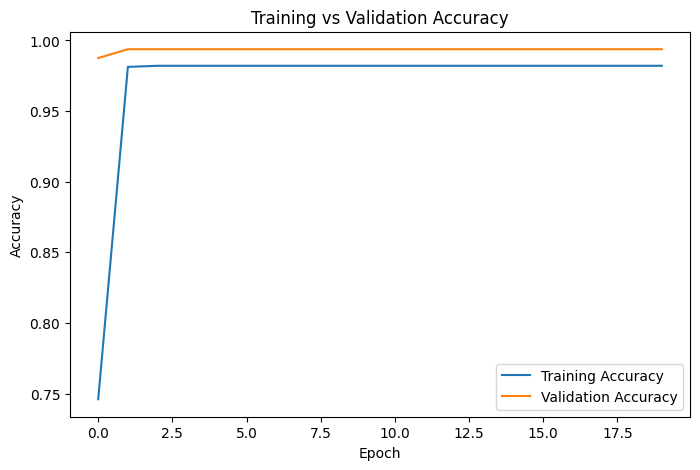

In [ ]:
## Task 4
## Plot training axxuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

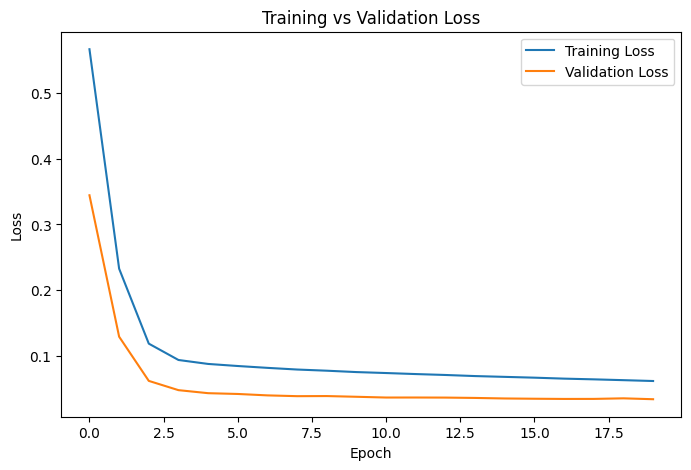

In [ ]:
## Plot training loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [38]:
## Evaluating Model
train_loss, train_acc = model.evaluate(X_train_processed, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test_processed, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9887499809265137
Testing Accuracy: 0.987500011920929


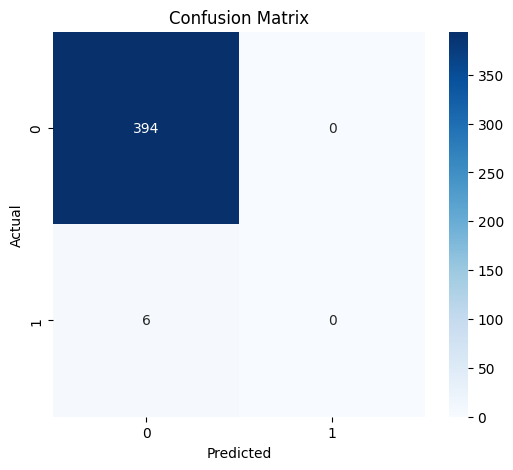

In [34]:
## Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
## classification Report 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

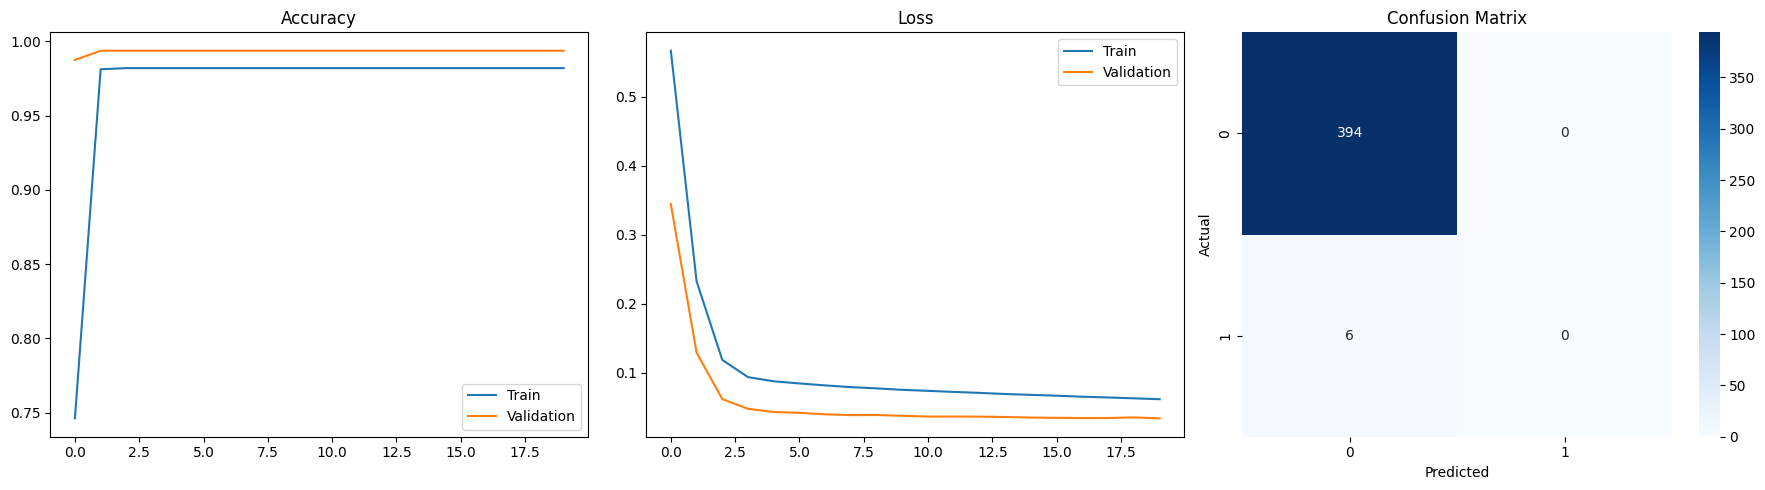

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title("Accuracy")
axes[0].legend()

# Loss Plot
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title("Loss")
axes[1].legend()

# Confusion Matrix
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[2])

axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()

# Save PNG
plt.savefig("results/evaluation_outputs.png")

plt.show()

In [24]:
## Task 5
## Experiment function
results = []

configs = [
    {"neurons": 16, "lr": 0.001, "epochs": 20},
    {"neurons": 32, "lr": 0.001, "epochs": 30},
    {"neurons": 64, "lr": 0.0005, "epochs": 40},
]

for config in configs:
    
    model = create_model(
        hidden_neurons=config["neurons"],
        learning_rate=config["lr"]
    )
    
    model.fit(
        X_train_processed,
        y_train,
        epochs=config["epochs"],
        batch_size=32,
        verbose=0
    )
    
    loss, acc = model.evaluate(X_test_processed, y_test, verbose=0)
    
    results.append({
        "Neurons": config["neurons"],
        "Learning Rate": config["lr"],
        "Epochs": config["epochs"],
        "Test Accuracy": acc
    })

results_df = pd.DataFrame(results)

results_df

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Neurons,Learning Rate,Epochs,Test Accuracy
0,16,0.0010,20,0.9850
1,32,0.0010,30,0.9850
2,64,0.0005,40,0.9875


In [31]:
results_df.to_csv("results/model_comparison_table.csv", index=False)

## Task 6
## Weights and Biases
Weights determine the importance of input features, while biases help shift activation values. Together they allow the network to learn relationships between inputs and outputs.

## Why Activation Functions Are Needed
Activation functions introduce non-linearity, enabling neural networks to learn complex patterns. Without them, the model behaves like a simple linear model.

## Learning Rate Effects
Too high → unstable training and overshooting minima
Too low → very slow learning and poor convergence

## Underfitting vs Overfitting
Underfitting occurs when the model is too simple to learn patterns
Overfitting occurs when the model memorizes training data and performs poorly on unseen data
Compare train and test accuracy to identify this behaviour